## 0. Iris flower dataset (\*)

In the whole exercise, we will work with the famous Iris flower dataset, which was collected in 1936 by Ronald Fisher, a statistician and biologist. Use the `datasets` module from scikit-learn to load the iris dataset.



&nbsp; a) Check keys on the loaded data and check what the different values for each key are.


In [162]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()

print(iris.keys())
#for value in iris.data[:5]:
#    print(value)

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])



&nbsp; b) Now insert the data into a DataFrame.


In [163]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [164]:
df_target = pd.DataFrame(iris["target"], columns=["class"])
df_target.head()

,class
0,0
1,0
2,0
3,0
4,0


In [165]:
df_with_target = pd.concat([df, df_target], axis=1)
df_with_target.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0



&nbsp; c) Do some EDA to get an understanding of the dataset.


In [166]:
df_with_target.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   class              150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [167]:
df_with_target.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000



&nbsp; d) Make a correlation heatmap to see how each feature is correlated to each other. What do the numbers mean?


<Axes: >

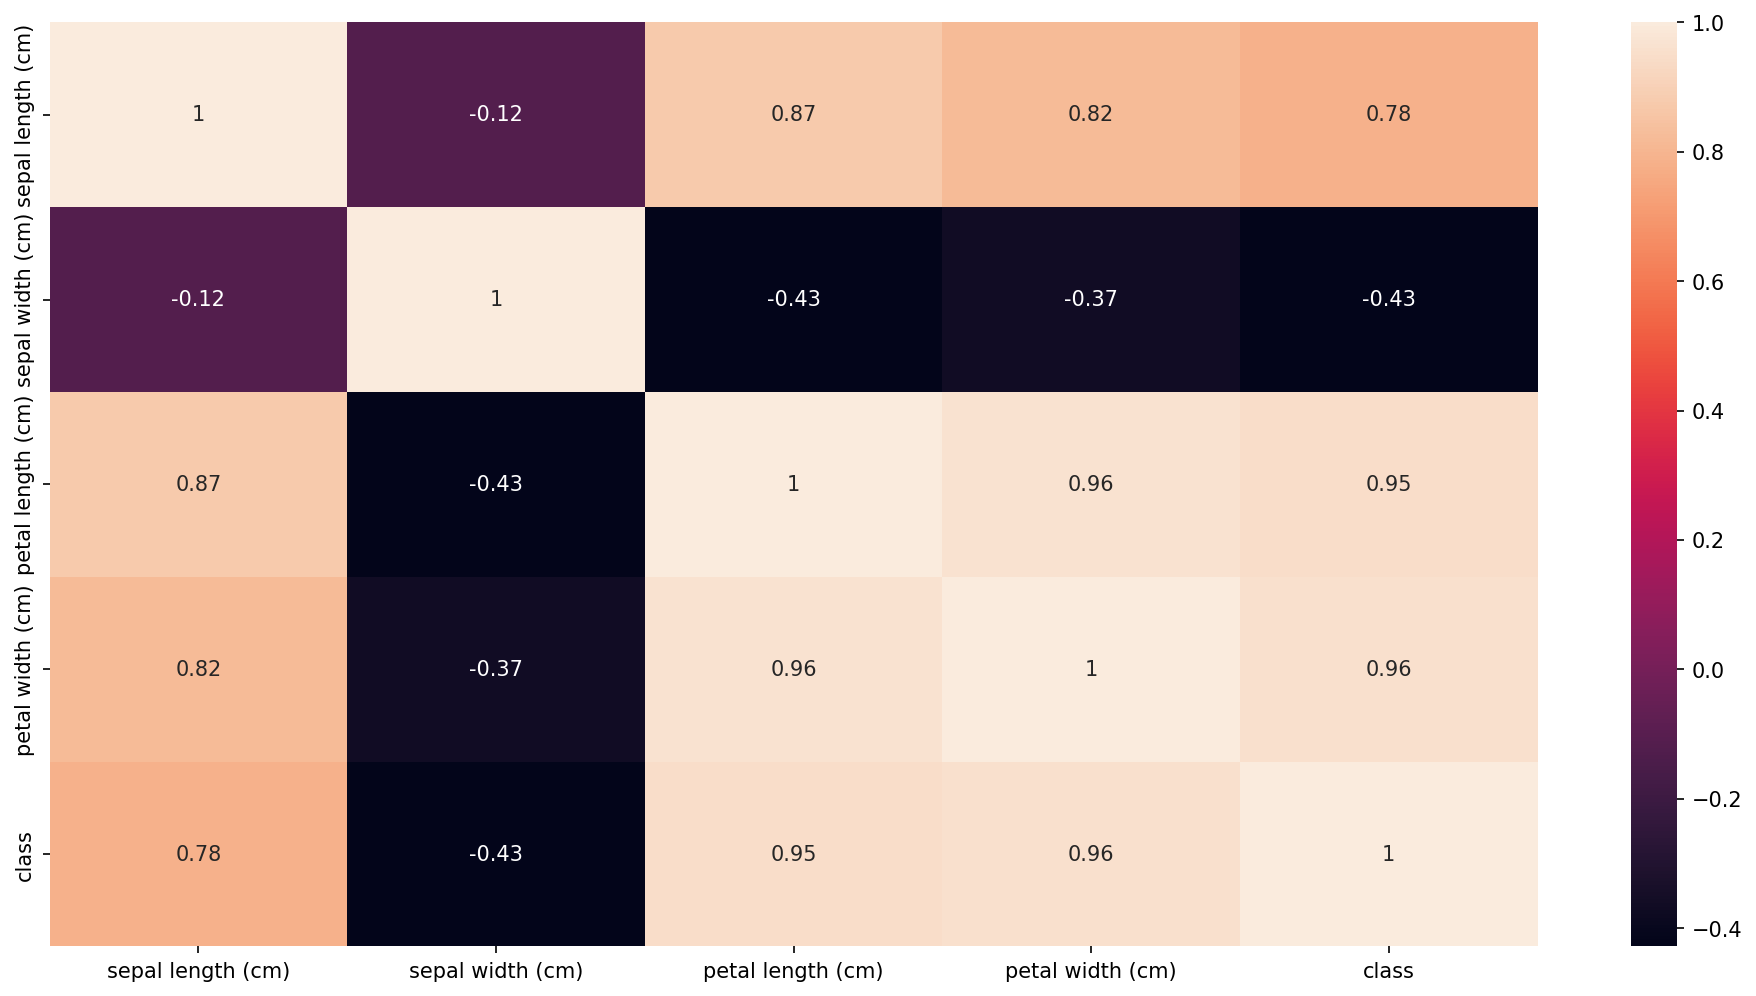

In [168]:
import matplotlib.pyplot as plt
import seaborn as sns

fig,ax = plt.subplots(1, figsize=(16,8), dpi=150)

sns.heatmap(df_with_target.corr(), annot=True)


&nbsp; e) Make a boxplot. The points outside of the boxplot are statistically calculated outliers using Tukey's rule for boxplot.


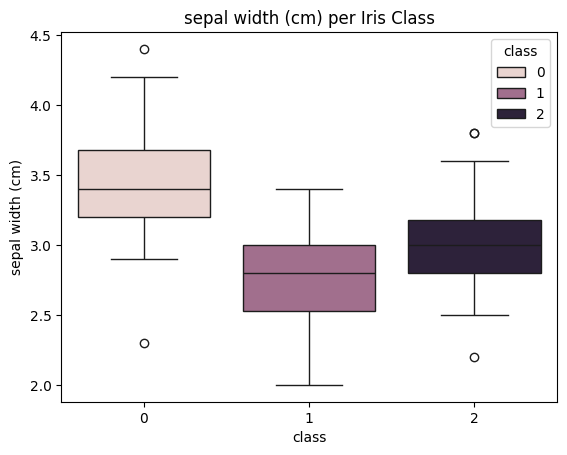

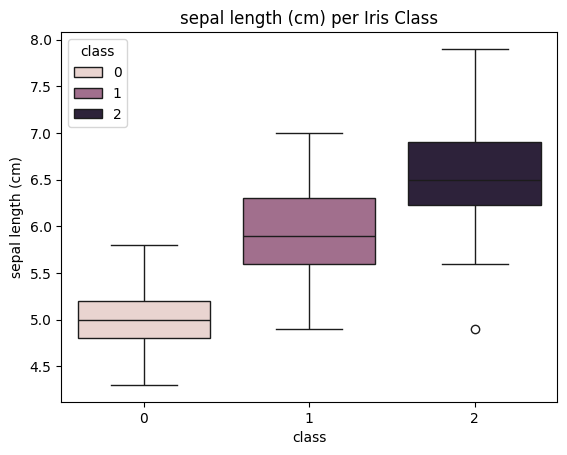

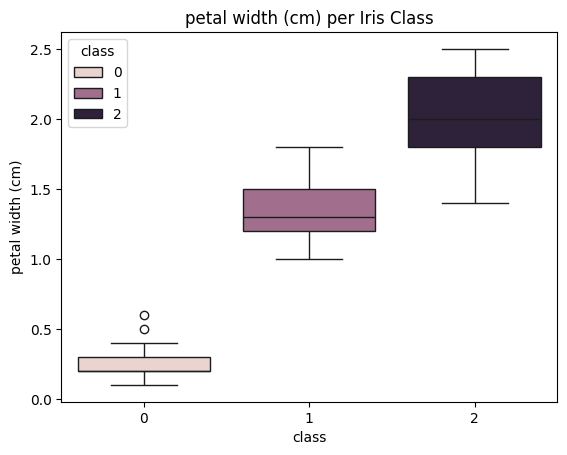

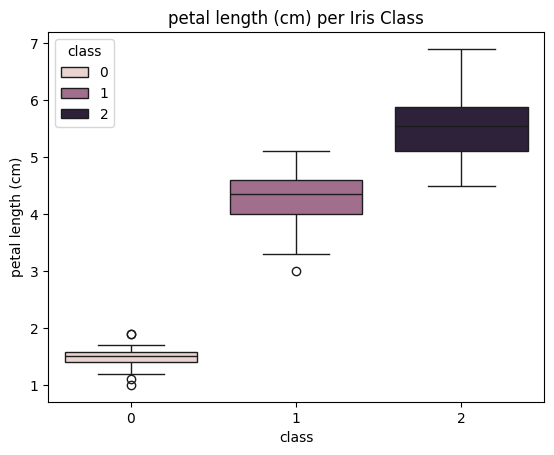

In [169]:
def plot_box(feature):
    sns.boxplot(data=df_with_target, x="class", y=feature, hue="class")
    plt.title(f"{feature} per Iris Class")
    plt.show()

# Exempelanrop
plot_box("sepal width (cm)")
plot_box("sepal length (cm)")
plot_box("petal width (cm)")
plot_box("petal length (cm)")



&nbsp; f) Now remove the outliers in data. (\*\*)

- Lower bound outlier: $Q_1 - 1.5\cdot IQR$
- Upper bound outlier: $Q_3 + 1.5\cdot IQR$

where $Q_1$ is the 1st quartile or 25 percentile, $Q_3$ is the 3rd quartile or 75 percentile and $IQR = Q_3-Q_1$ is the interquartile range.

&nbsp; g) Do train|test split on the dataset and then scale it with feature standardization.

&nbsp; h) Classify using logistic regression

&nbsp; i) Classify the first 10 values of your $X_{test}$ and compare it manually with your labels.

&nbsp; j) Evaluate your model using classification report and confusion matrix. 
